# Decision Tree Regressor

## Review 1 — Regression Track

**Dataset:** Ames Housing  
**Target:** `SalePrice`  
**Notebook:** `06_decision_tree_regressor.ipynb`

This notebook implements the **Decision Tree Regressor** as one of the ten required regression algorithms.  
All regression notebooks use the same dataset, `random_state=42`, 80:20 held-out split, feature engineering, missing-value handling, and leakage-safe preprocessing so that model comparisons are fair.

## 1. Imports and Project Paths

In [1]:
from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate the project root whether Jupyter is started from the repository root
# or from Review-1/notebooks.
cwd = Path.cwd().resolve()
candidates = [cwd] + list(cwd.parents)
PROJECT_ROOT = next(
    (p for p in candidates if (p / "src" / "preprocessing.py").exists()),
    cwd
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from preprocessing import (
    RANDOM_STATE, TARGET, load_and_engineer, split_data,
    remove_training_outliers, make_preprocessor, make_polynomial_preprocessor,
    regression_metrics
)

DATA_PATH = PROJECT_ROOT / "data" / "AmesHousing.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load Dataset and Perform the Required Audit

We report dataset shape, data types, missing-value counts, duplicate rows, and the target distribution.

In [2]:
df, X, y = load_and_engineer(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nData types:")
display(df.dtypes.value_counts().rename_axis("dtype").reset_index(name="count"))

print("\nMissing values — top 20:")
display(df.isna().sum().sort_values(ascending=False).head(20).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(y.describe().to_frame("SalePrice"))

print("\nCategorical features:", len(X.select_dtypes(include="object").columns))
print("Numerical features:", len(X.select_dtypes(include=np.number).columns))

Dataset shape: (2930, 84)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,TotalSF,TotalBathrooms
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,NaN,NaN,0,5,2010,WD,Normal,215000,2736.0,2.0
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,MnPrv,NaN,0,6,2010,WD,Normal,105000,1778.0,1.0
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,NaN,Gar2,12500,6,2010,WD,Normal,172000,2658.0,1.5
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,NaN,NaN,0,4,2010,WD,Normal,244000,4220.0,3.5
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,MnPrv,NaN,0,3,2010,WD,Normal,189900,2557.0,2.5



Data types:


,dtype,count
0,object,43
1,int64,28
2,float64,13



Missing values — top 20:


,missing_count
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Finish,159
Garage Yr Blt,159
Garage Qual,159



Duplicate rows: 0

Target distribution:


,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000



Categorical features: 44
Numerical features: 37


## 3. Exploratory Data Analysis

The following cells provide the Review 1 EDA requirements: feature distributions, target distribution, correlation heatmap, and feature-target scatter plots.

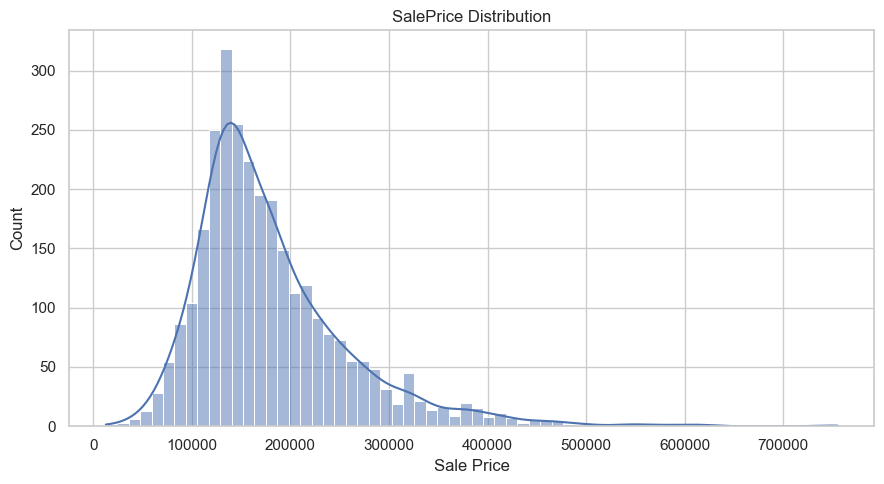

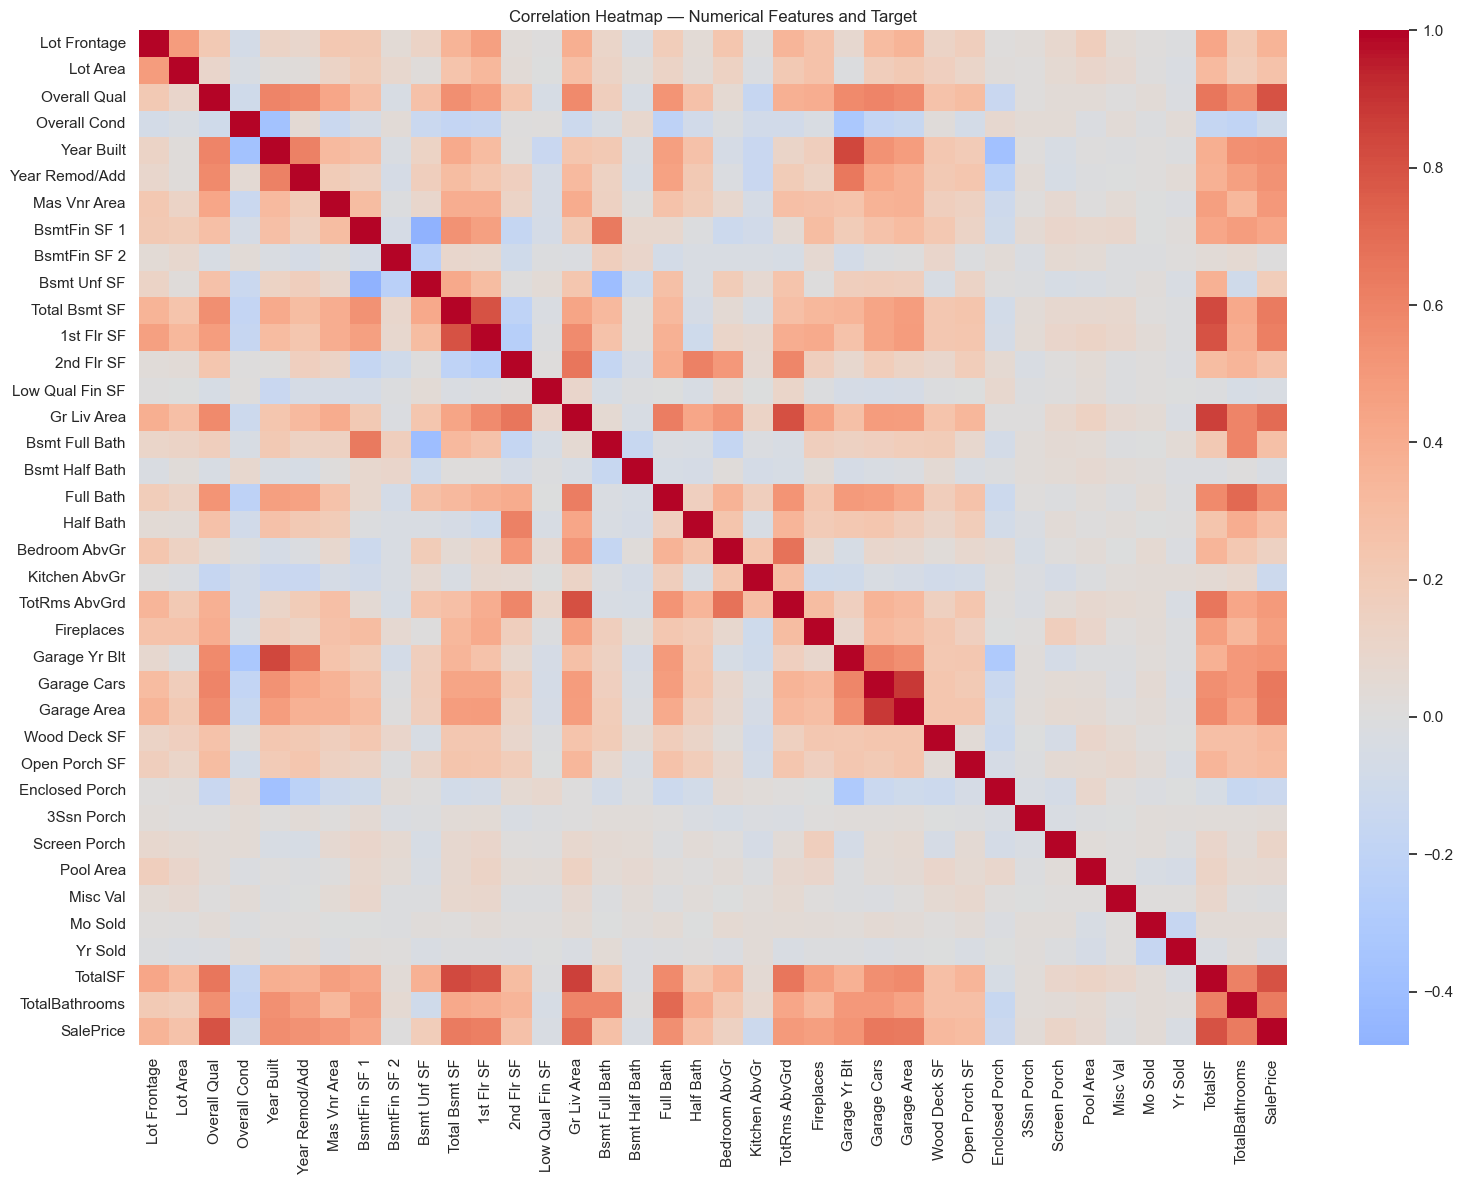

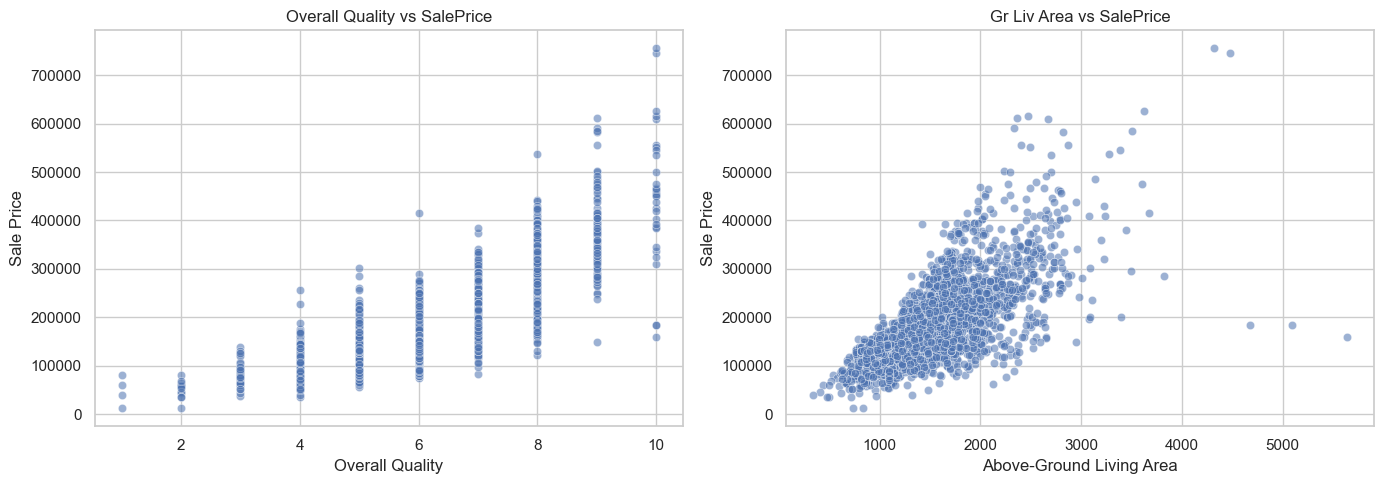

In [ ]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()



plt.figure(figsize=(9, 5))

sns.histplot(y, kde=True)

plt.title("SalePrice Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


corr_cols = numeric_cols + [TARGET]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap — Numerical Features and Target")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.scatterplot(
    data=df,
    x="Overall Qual",
    y=TARGET,
    ax=axes[0],
    alpha=0.55
)

axes[0].set_title("Overall Quality vs SalePrice")
axes[0].set_xlabel("Overall Quality")
axes[0].set_ylabel("Sale Price")


sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y=TARGET,
    ax=axes[1],
    alpha=0.55
)

axes[1].set_title("Gr Liv Area vs SalePrice")
axes[1].set_xlabel("Above-Ground Living Area")
axes[1].set_ylabel("Sale Price")


plt.tight_layout()
plt.show()

EDA — Team Observation

* The SalePrice distribution is right-skewed, with most houses having lower to moderate prices and fewer houses having very high prices.
* Overall Qual has a strong positive relationship with SalePrice, meaning higher-quality houses generally have higher prices.
* Gr Liv Area also shows a positive relationship with SalePrice, where larger living areas generally correspond to higher prices.
* The correlation heatmap shows that Overall Qual is one of the features most strongly associated with SalePrice.
* A few outliers can be observed in Gr Liv Area, where some houses have unusually large living areas and high sale prices.
* Overall, house quality and living area appear to be important factors in predicting SalePrice.

## 4. Preprocessing and Feature Engineering

### Engineered features

Two predictor-only features are created:

- `TotalSF` = basement + first-floor + second-floor area.
- `TotalBathrooms` = full bathrooms + half bathrooms + basement bathrooms, with half bathrooms counted as 0.5.

Identifier columns (`Order` and `PID`) are excluded because they identify records rather than represent meaningful property characteristics.

The train/test split is created before data-driven imputation, encoding, scaling, or outlier threshold estimation.

In [ ]:
X_train, X_test, y_train, y_test = split_data(X, y)

print("Before outlier treatment:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train, y_train, outlier_threshold = remove_training_outliers(
    X_train, y_train, feature="Gr Liv Area", multiplier=3.0
)

print(f"\nTraining outlier threshold for Gr Liv Area: {outlier_threshold:.2f}")
print("After outlier treatment:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTarget means:")
print("Train:", y_train.mean())
print("Test :", y_test.mean())

Before outlier treatment:
X_train: (2344, 81)
X_test : (586, 81)

Training outlier threshold for Gr Liv Area: 3570.75
After outlier treatment:
X_train: (2338, 81)
X_test : (586, 81)

Target means:
Train: 177871.19118905047
Test : 189651.46928327644


### Preprocessing Strategy

- Numerical missing values → median imputation.
- Categorical missing values → most-frequent imputation.
- Categorical variables → one-hot encoding with unknown-category protection.
- Scale-sensitive algorithms → numerical standardization fitted on training data only.
- Tree-based algorithms → no feature scaling required.
- Extreme `Gr Liv Area` values are checked and training-set extremes above a 3×IQR upper threshold are removed; the threshold is learned only from the training set.

## 5. Train Decision Tree Regressor

The model is trained only on the training split. The held-out test set is used only for final evaluation.

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

MODEL_NAME = "Decision Tree Regressor"
RESULT_FILE = "decision_tree_regressor"

model = Pipeline([
    ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
    ("model", DecisionTreeRegressor(max_depth=15, min_samples_split=2, random_state=RANDOM_STATE))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 6. Test-Set Evaluation

The mandatory regression metrics are **R², RMSE, and MAE**.

In [6]:
metrics = regression_metrics(y_test, y_pred)
metrics_df = pd.DataFrame([metrics], index=[MODEL_NAME])
display(metrics_df)

# Save a machine-readable result for the comparison notebook.
result_path = RESULTS_DIR / f"{RESULT_FILE}.csv"
metrics_df.reset_index(names="Model").to_csv(result_path, index=False)

print(f"Saved results to: {result_path}")

,R2,RMSE,MAE
Decision Tree Regressor,0.814416,38573.650131,24265.131773


Saved results to: /Users/venkataramana/Documents/SEMESTERS/5TH SEMESTER/MACHINE LEARNING/ML_Capstone/Review-1/results/decision_tree_regressor.csv


## 7. Feature Importance

A tree-based model provides feature importance values. The plot below is required for the best tree-based model in the final review; this notebook provides the same analysis for this algorithm.

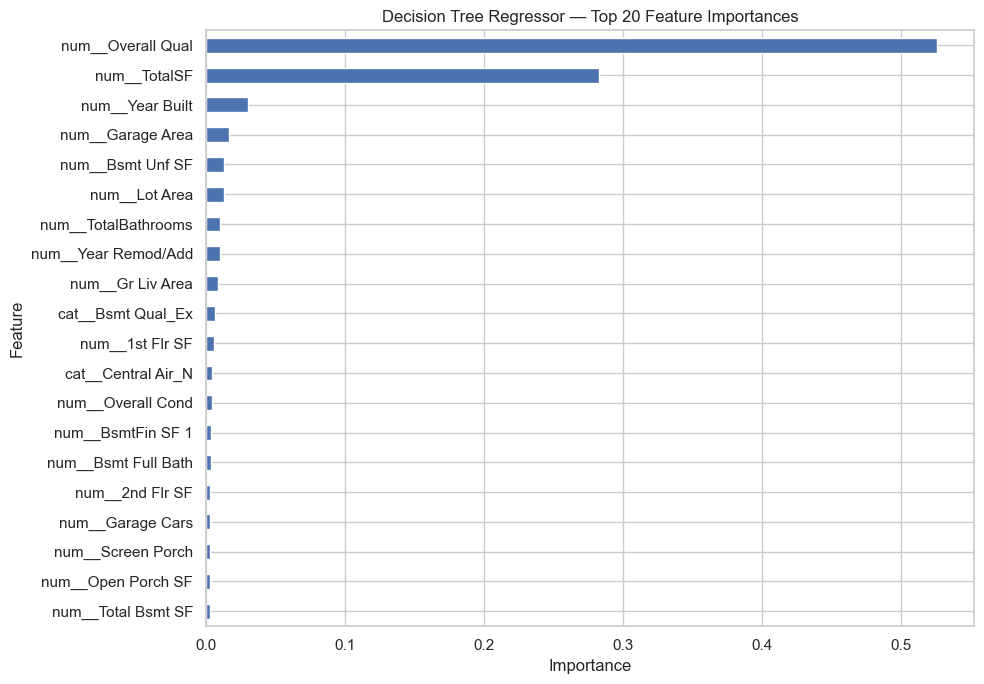

In [7]:
preprocessor = model.named_steps["preprocess"]
estimator = model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
importance = pd.Series(estimator.feature_importances_, index=feature_names)
top_importance = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top_importance.sort_values().plot(kind="barh")
plt.title(f"{MODEL_NAME} — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Prediction Diagnostics

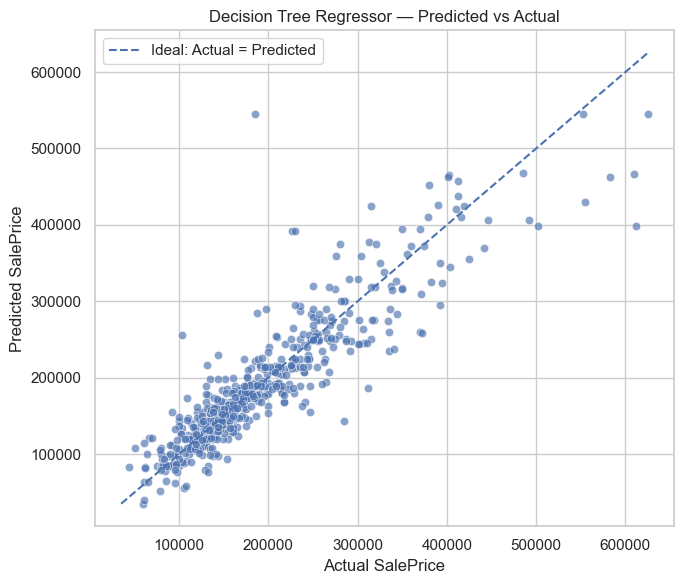

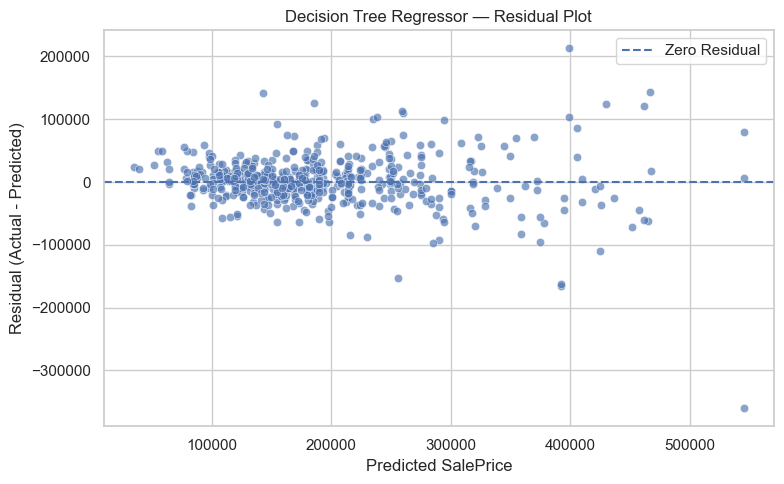

In [ ]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.65)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--", label="Ideal: Actual = Predicted")
plt.title(f"{MODEL_NAME} — Predicted vs Actual")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.legend()
plt.tight_layout()
plt.show()


residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.65)
plt.axhline(0, linestyle="--", label="Zero Residual")
plt.title(f"{MODEL_NAME} — Residual Plot")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Cross-Validation Note

The course requires 5-fold cross-validated R² for the **two best-performing models**. After the common comparison table identifies those two models, run 5-fold CV for them and record the results in the final comparison documentation.

In [9]:
import joblib

model_path = MODELS_DIR / f"{RESULT_FILE}.joblib"
joblib.dump(model, model_path)
print(f"Saved fitted model to: {model_path}")

Saved fitted model to: /Users/venkataramana/Documents/SEMESTERS/5TH SEMESTER/MACHINE LEARNING/ML_Capstone/Review-1/models/decision_tree_regressor.joblib
